# SnS Lab

Merged notebook: Experiments **1B**, **2**, **3A**, **3B**, and **3C**.

**Name:** SIDDHARTH SHARMA <br>
**ID/Roll Number:** BT25ECE068


# EXPERIMENT 1B
Aim

Read and plot realworld signals:- Voice & image
Display values at any random locations in the signal.

In [ ]:
import cv2
import numpy as np
from PIL import Image
import os

# 1. AUDIO: Display amplitude at a specific sample index
# Using the audio_array already loaded and normalized in previous cells
sample_index = 10000
if 'audio_array' in globals():
    amplitude = audio_array[sample_index]
    print(f"Audio Amplitude at index {sample_index}: {amplitude:.6f}")

# 2. IMAGE: Display color (RGB) at a specific (x, y) location
# Using a standard system image available in most Colab/Linux environments
img_path = '/content/sample_data/wp7472869.jpg'
if not os.path.exists(img_path):
    # Create a dummy image if the specific system icon is missing
    img_np = np.zeros((100, 100, 3), dtype=np.uint8)
    img_np[20:80, 20:80] = [255, 128, 0] # Orange square
    print("Sample system image not found, using a generated synthetic image.")
else:
    img = Image.open(img_path).convert('RGB')
    img_np = np.array(img)

x, y = 50, 50 # Coordinates
color = img_np[y, x]
print(f"Image Color (RGB) at pixel ({x}, {y}): {color}")

# 3. VIDEO: Helper function for video signal inspection
def get_video_pixel(video_path, frame_number, x, y):
    if not os.path.exists(video_path):
        return "Video file not found"
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ret, frame = cap.read()
    cap.release()
    if ret:
        # OpenCV returns BGR, we convert to RGB
        return frame[y, x][::-1]
    return "Could not read frame"

print("\nHelper for video signals: Use 'get_video_pixel(path, frame, x, y)' to extract pixel values.")

Audio Amplitude at index 10000: -0.005645
Image Color (RGB) at pixel (50, 50): [1 1 1]

Helper for video signals: Use 'get_video_pixel(path, frame, x, y)' to extract pixel values.


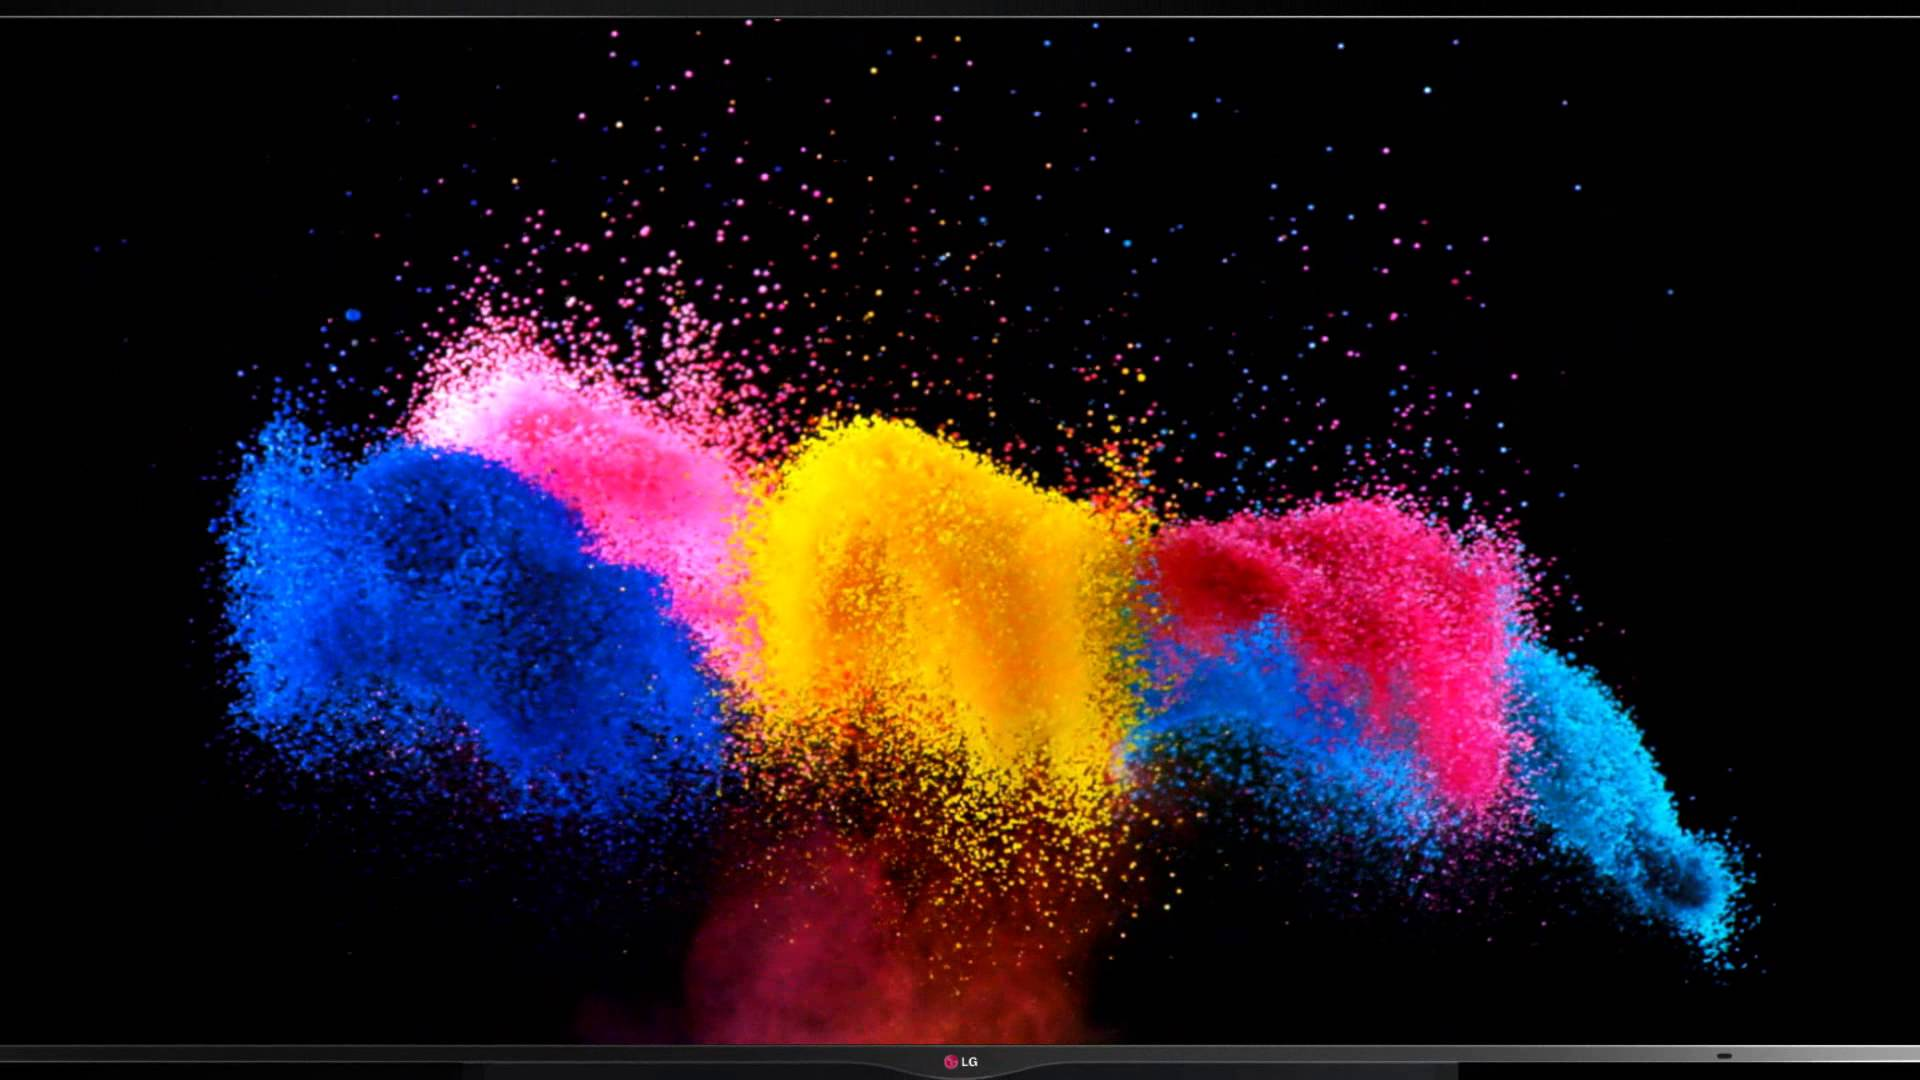

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

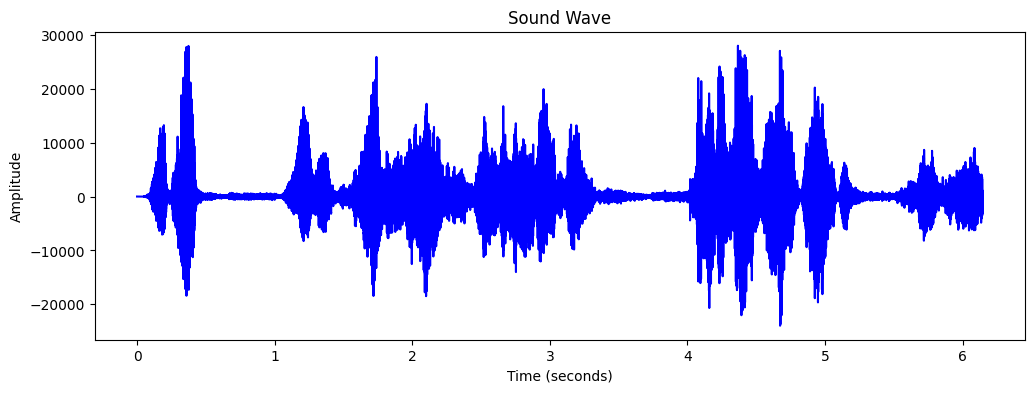

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import wave


wav_file = wave.open("/content/sample_data/voice.wav", "rb")

sample_rate = wav_file.getframerate()
n_frames = wav_file.getnframes()
n_channels = wav_file.getnchannels()
audio_data = wav_file.readframes(n_frames)

audio_array = np.frombuffer(audio_data, dtype=np.int16)


if n_channels > 1:
    audio_array = audio_array.reshape(-1, n_channels)
    audio_array = audio_array[:, 0]

time_axis = np.linspace(0, n_frames / sample_rate, num=n_frames)

plt.figure(figsize=(12, 4))
plt.plot(time_axis, audio_array, color="blue")
plt.title("Sound Wave")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

# EXPERIMENT 2
Aim

Perform various scaling/shifting/flipping operations on
real world signal (use own voices). Display & Hear the changes and note observations.

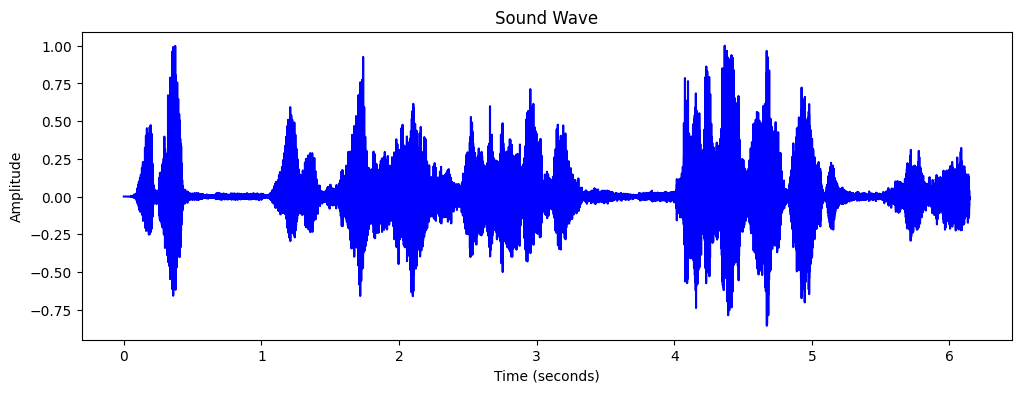

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import wave


wav_file = wave.open("/content/sample_data/voice.wav", "rb")

sample_rate = wav_file.getframerate()
n_frames = wav_file.getnframes()
n_channels = wav_file.getnchannels()
audio_data = wav_file.readframes(n_frames)

audio_array = np.frombuffer(audio_data, dtype=np.int16)


if n_channels > 1:
    audio_array = audio_array.reshape(-1, n_channels)
    audio_array = audio_array[:, 0]

# Normalize the audio_array amplitude to a range between -1 and 1
max_amplitude = np.max(np.abs(audio_array))
if max_amplitude > 0:
    audio_array = audio_array / max_amplitude

time_axis = np.linspace(0, n_frames / sample_rate, num=n_frames)

plt.figure(figsize=(12, 4))
plt.plot(time_axis, audio_array, color="blue")
plt.title("Normalized Sound Wave")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

### Time Shifting the Normalized Audio Signal
To shift the audio signal along the time axis, we can pad the `audio_array` with zeros. A positive shift value will delay the signal (shift it to the right), while a negative shift value will advance it (shift it to the left).

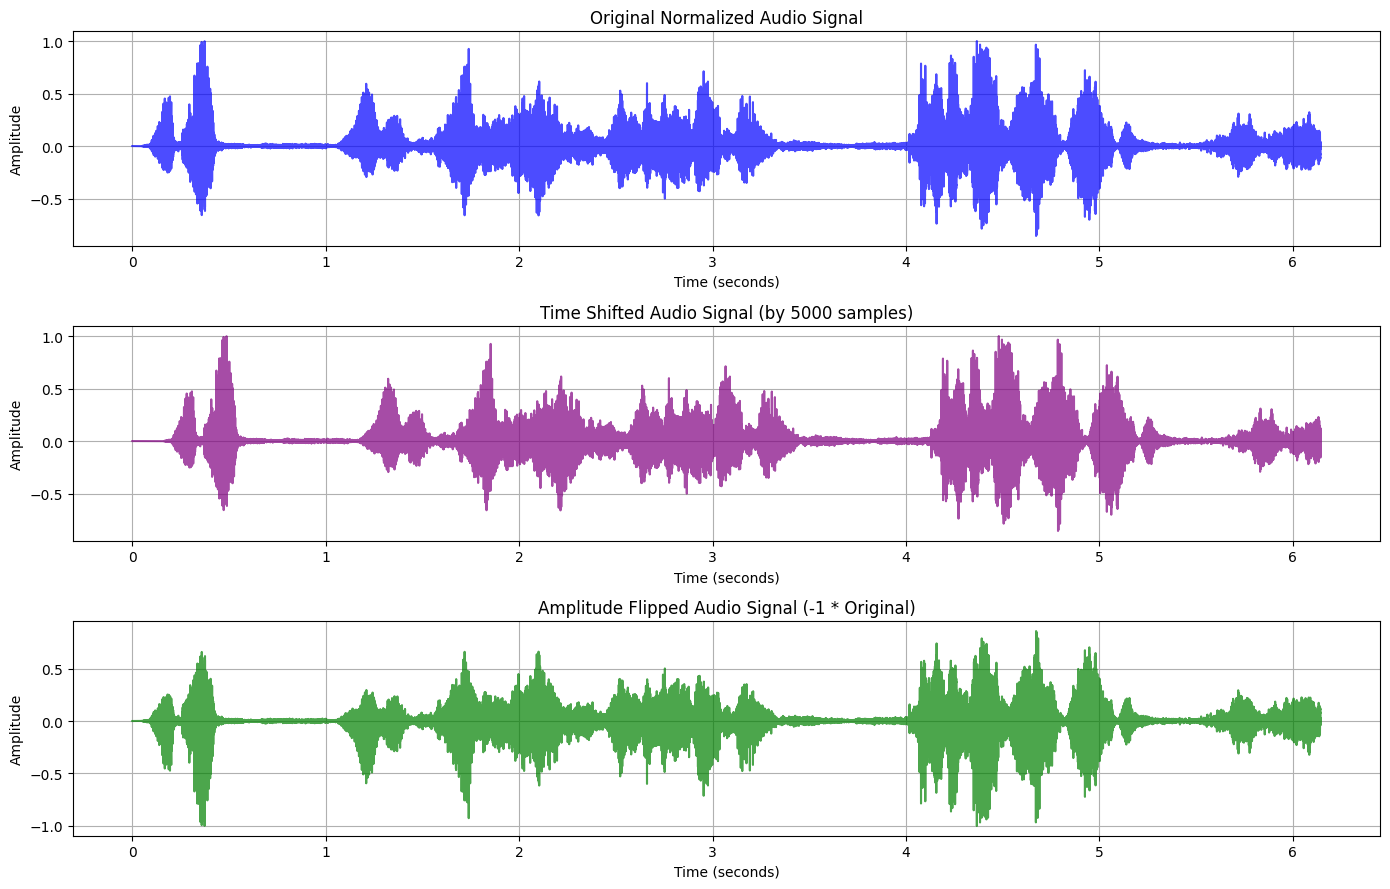

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the number of samples to shift
shift_samples = 5000  # Shift forward by 5000 samples

# Create a new array for the shifted audio
shifted_audio_time = np.zeros_like(audio_array, dtype=audio_array.dtype)

if shift_samples > 0:
    # Positive shift: pad the beginning with zeros
    # Example: [0,0,0, s1, s2, s3]
    shifted_audio_time[shift_samples:] = audio_array[:-shift_samples]
elif shift_samples < 0:
    # Negative shift: pad the end with zeros
    # Example: [s4, s5, s6, 0, 0, 0]
    shifted_audio_time[:shift_samples] = audio_array[-shift_samples:]
else:
    # No shift
    shifted_audio_time = audio_array.copy()

# Amplitude Flipping (Inversion)
amplitude_flipped_audio = -audio_array

# Plotting the original, time-shifted, and amplitude-flipped signals
plt.figure(figsize=(14, 9))

plt.subplot(3, 1, 1)
plt.plot(time_axis, audio_array, color='blue', alpha=0.7)
plt.title('Original Normalized Audio Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(time_axis, shifted_audio_time, color='purple', alpha=0.7)
plt.title(f'Time Shifted Audio Signal (by {shift_samples} samples)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(time_axis, amplitude_flipped_audio, color='green', alpha=0.7)
plt.title('Amplitude Flipped Audio Signal (-1 * Original)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

---

# Experiments 3A–3C

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## 3A — Periodic + non-periodic sinusoids

Edit the parameters below, then run the cell.

In [ ]:
# parameters (edit these)
A_p = 5.0       # amplitude of periodic sinusoid
f_p = 1.0       # frequency of periodic sinusoid
A_np = 5.0      # amplitude of non-periodic sinusoid
w_np = 5.0      # angular frequency of non-periodic sinusoid
f_np = w_np / (2 * np.pi)
dt = 0.1        # interval between steps

n = np.arange(0, 5 + dt, dt)

w_p = 2 * np.pi * f_p

x_p = A_p * np.sin(w_p * n)
x_np = A_np * np.sin(w_np * n)
x_sum = x_p + x_np

fig, axes = plt.subplots(3, 1, figsize=(10, 8))

axes[0].stem(n, x_p)
axes[0].set_title("Periodic:")
axes[0].grid(True)

axes[1].stem(n, x_np)
axes[1].set_title("Non-periodic:")
axes[1].grid(True)

axes[2].stem(n, x_sum)
axes[2].set_title("Sum of the two")
axes[2].set_xlabel("n")
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 3B — Roots of $x^2 + 1 = 0$ in the complex plane

3D surface of $|z^2 + 1|$ with zeros marked at $\pm i$.

In [ ]:
# roots of x^2 + 1 = 0  →  x = ±i
coeffs = [1, 0, 1]
roots = np.roots(coeffs)

re = np.linspace(-2, 2, 80)
im = np.linspace(-2, 2, 80)
Re, Im = np.meshgrid(re, im)
Z = Re + 1j * Im
mag = np.abs(Z**2 + 1)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(Re, Im, mag, cmap="viridis", alpha=0.85, linewidth=0, antialiased=True)
ax.scatter(
    roots.real,
    roots.imag,
    np.zeros(len(roots)),
    color="red",
    s=80,
    depthshade=False,
    label="roots (zeros)",
)
for r in roots:
    ax.text(r.real, r.imag, 0.15, f"{r.real:.0f}{r.imag:+.0f}j", color="red")

ax.set_xlabel("Re")
ax.set_ylabel("Im")
ax.set_zlabel(r"$|z^2 + 1|$")
ax.set_title(r"$|z^2 + 1|$ over the complex plane (zeros at $\pm i$)")
ax.legend(loc="upper left")

print("Roots of x^2 + 1 = 0:")
for r in roots:
    print(f"  {r}")

plt.tight_layout()
plt.show()

## 3C — Complex exponential $e^{j\omega t}$

3D helix plus 2D complex-plane and Re/Im vs time views. Edit $\omega$ below.

In [ ]:
# parameters (edit these)
w = 2 * np.pi   # angular frequency ω

t = np.linspace(0, 2, 400)
z = np.exp(1j * w * t)
theta = np.linspace(0, 2 * np.pi, 200)

fig = plt.figure(figsize=(12, 8))

# --- 3D helix ---
ax = fig.add_subplot(2, 2, (1, 2), projection="3d")
ax.plot(z.real, z.imag, t, lw=1.5, label=r"$e^{j\omega t}$")
ax.scatter([z.real[0]], [z.imag[0]], [t[0]], s=60, color="red", label="t = 0")
ax.plot(np.cos(theta), np.sin(theta), np.zeros_like(theta), "k--", lw=0.8, label="unit circle (t=0)")
ax.set_xlabel("Re = cos(ωt)")
ax.set_ylabel("Im = sin(ωt)")
ax.set_zlabel("t")
ax.set_title(rf"3D helix: $e^{{j\omega t}}$, $\omega={w:.3g}$")
ax.legend(loc="upper left")

# --- 2D complex plane ---
ax = fig.add_subplot(2, 2, 3)
ax.plot(np.cos(theta), np.sin(theta), "k--", lw=0.8, label="unit circle")
ax.plot(z.real, z.imag, lw=1.5, label=r"$e^{j\omega t}$")
ax.scatter([z.real[0]], [z.imag[0]], s=60, zorder=3, color="red", label="t = 0")
ax.axhline(0, color="k", lw=0.8)
ax.axvline(0, color="k", lw=0.8)
ax.set_aspect("equal")
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel("Re")
ax.set_ylabel("Im")
ax.set_title("2D complex plane")
ax.grid(True)
ax.legend(loc="upper right")

# --- 2D Re & Im vs time ---
ax = fig.add_subplot(2, 2, 4)
ax.plot(t, z.real, label=r"Re $= \cos(\omega t)$")
ax.plot(t, z.imag, label=r"Im $= \sin(\omega t)$")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("t")
ax.set_ylabel("amplitude")
ax.set_title(r"2D: $e^{j\omega t} = \cos(\omega t) + j\sin(\omega t)$")
ax.grid(True)
ax.legend()

print(f"ω = {w}")
print(f"|e^{{jωt}}| ≈ {np.max(np.abs(z)):.6f} (should be 1)")

plt.tight_layout()
plt.show()